In [1]:
import tensorflow as tf
import numpy as np
from matplotlib import pyplot as plt

In [3]:
X=np.load("/content/X.npy") # This input is having sign language images of digits 0 to 9
Y=np.load("/content/Y.npy") # The encoded label outputs of digits 0 to 9

In [4]:
X.shape # There are 2064 images are there in total in this datset. Each image is 64x64 in size

(2062, 64, 64)

In [5]:
X[600,:,:].shape # Accessing one single image (600th Image)

(64, 64)

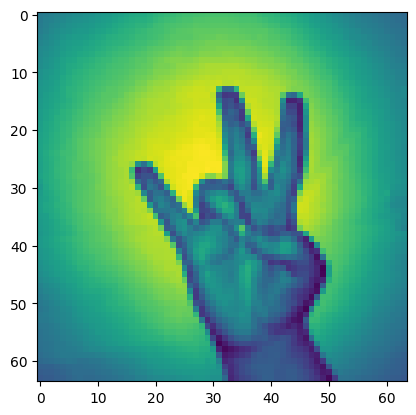

In [14]:
plt.imshow(X[600,:,:]) # Displaying one single image

In [15]:
Y[600]
# encoded output of 600th image.
#We can see one at the index position of 2. Hence this is a sign representation of digit 2

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [ ]:
Y

array([[1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.]])

In [20]:
# Split the data in to train and test
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest=train_test_split(X,Y,test_size=0.2,random_state=48)

In [21]:
xtrain.shape, xtest.shape

((1649, 64, 64), (413, 64, 64))

In [22]:
64*64

4096

In [23]:
Xtrain=xtrain.reshape(1649,64*64)
# Reshape the matrix image data into a vector
# 64x64 image reshaped into 1x4096
# Totally 1649 images are there in Xtrain, hence now the xtrain size is 1649x4096

In [24]:
Xtrain.shape

(1649, 4096)

In [25]:
Xtest=xtest.reshape(413,64*64) # Simillary reshape the Xtest also

In [26]:
Xtest.shape

(413, 4096)

In [27]:
# Normalize the data between 0 to 1. Image pixels always have the maximum value as 255.
# Divide each pixel with 255, so the data scaled between 0 to 1
Xtrain1=Xtrain/255.
Xtest1=Xtest/255.

In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [29]:
img_classifier=Sequential()
# Define the neural network as a sequentail model (Sequence of layers from input to output)

In [30]:
img_classifier.add(Dense(units=512,activation='relu',input_dim=4096))
# through the function Dense, the layers can be added in to neural networks
#input_dim is having the information about number of neurons in the input layer
# units is having the information about the number of neurons in the output side of that layer.
# units = 512 is nothing but the number of neurons in the first hidden layer
#( first hidden layer is exist at the output side of input layer)
# 'relu' activation function is prefred always in hidden layers

img_classifier.add(Dense(units=256,activation='relu'))
#units =256 is the number of neurons in the second hidden layer
# input_dim is not required here as it is a sequential model, the network knows that the
                     #second hidden layer will recieve the input from first hiiden layer (512 neurons)

img_classifier.add(Dense(units=10,activation='softmax'))
#The last dense layer is the output layer.
#The number of neurons in the output layer is number of classes for multiclass problem
# For multi-class problem, Softmax activation function is prefered
#The number of neurons in the output layer is "one" for binary class problem
# For binary class problem, sigmoidal activation function is prefered.

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [34]:
img_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,694,688 (25.54 MB)

 Trainable params: 2,231,562 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,463,126 (17.03 MB)

In [32]:
img_classifier.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

# For compiling the model, wee need to provide the optimizer detail.
# There are many gradiant decent versions of optimizers are available, here we have used adam
# Loss which the optmizer need to minimize need to be specified.
# For multi-class problem, we need to give categorical_crossentropy as loss
# For binary class problem, we need to give binary_crossentropy

In [33]:
img_classifier.fit(Xtrain1,ytrain,batch_size=32,epochs=100)
# for the fitting the model we need to provide train input and output
# BAtch size determine for howmany samples once the weights need to be updated (batch gradient descent detail)
# Epochs times the the network run again and agin and update the weights to produce minimum error

Epoch 1/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.0910 - loss: 2.3065
Epoch 2/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1134 - loss: 2.3023
Epoch 3/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1286 - loss: 2.2988
Epoch 4/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1534 - loss: 2.2858
Epoch 5/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.1783 - loss: 2.2482
Epoch 6/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2317 - loss: 2.1641
Epoch 7/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.2711 - loss: 2.0493
Epoch 8/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3062 - loss: 1.9578
Epoch 9/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3238 - loss: 1.8492
Epoch 10/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3499 - loss: 1.7928
Epoch 11/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.3924 - loss: 1.7009
Epoch 12/100
52/52 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy

In [35]:
img_classifier.evaluate(Xtest1,ytest)
# evaluate the model for the test data

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 63ms/step - accuracy: 0.6804 - loss: 0.9358


[0.9358413815498352, 0.6803874373435974]

In [36]:
img_classifier.predict(Xtest1[1].reshape(1,-1)).round()
#Predicting the output for the given input image

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 349ms/step


array([[0., 0., 1., 0., 0., 0., 0., 0., 0., 0.]], dtype=float32)

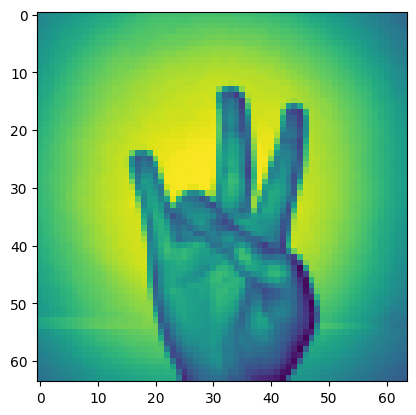

In [37]:
plt.imshow(xtest[1])

In [38]:
ytest[1] # Actual output of the input Xtest[1]

array([0., 0., 1., 0., 0., 0., 0., 0., 0., 0.])

In [39]:
img_classifier.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │     2,097,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,694,688 (25.54 MB)

 Trainable params: 2,231,562 (8.51 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 4,463,126 (17.03 MB)

input layer neurons = 4096

hidden layer-1 neurons = 512

Weights in the the first layer (b/w inp and hid1) = 4096*512 = 2097152

Bias in the first hidden layer = 512

Total number of parameter in the first layer = 4096*512 +512 = 2097664

Number of neurons in the second hidden layer = 256

Total number of parameter in the second layer(b/w hid 1 and hid 2) = 512*256 +256 = 131328

Number of neurons in the output layer = 10

Total number of parameter in the last layer(b/w hid 2 and output) = 256*10 +10 = 2570

In total this network need to train 2097664+131328+2570 = 2,231,562 parameters.
